## ALGORITHM 2: HIERARCHICAL CLUSTERING

### Definition
Creates a **tree-like structure (dendrogram)** of clusters. Can be:
- **Agglomerative**: Bottom-up (start with individuals, merge)
- **Divisive**: Top-down (start with all, split)

### Indian Analogy: Joint Family Tree 👨‍👩‍👧‍👦
```
                    [Sharma Parivar]
                          |
            ┌─────────────┴─────────────┐
      [Bade Papa]                 [Chote Papa]
            |                           |
      ┌─────┴─────┐               ┌─────┴─────┐
  [Ramesh]    [Suresh]        [Mukesh]    [Dinesh]
      |           |               |           |
   [Kids]      [Kids]          [Kids]      [Kids]

## Customer Segmentation

Customers with
    Monthly Spend
    Visit Frequency




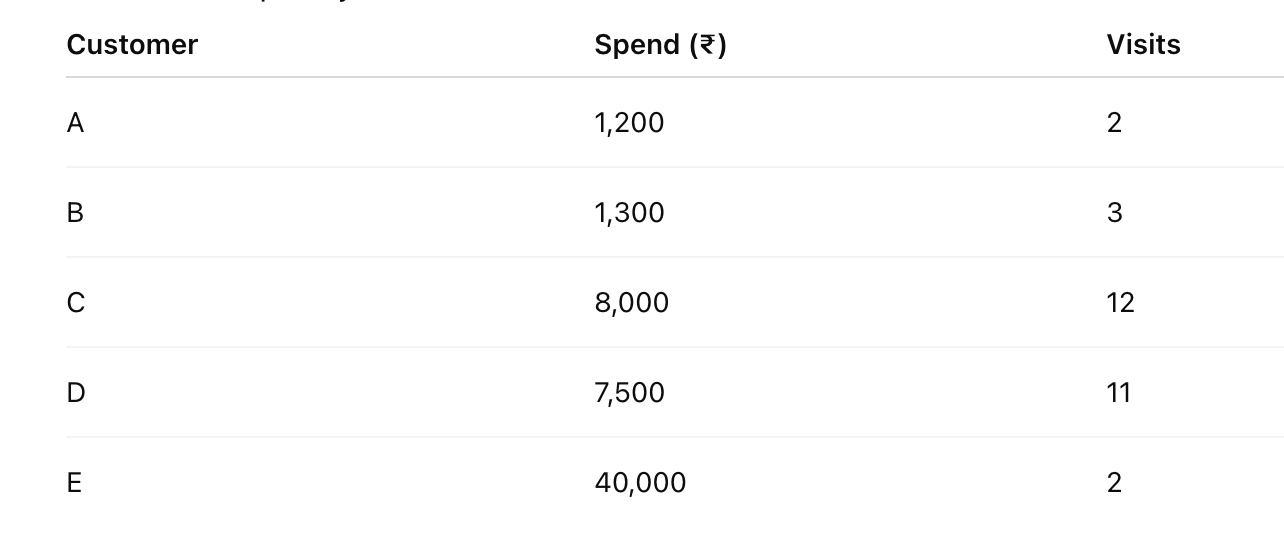

    A + B   =>  (Low Spenders)
    C + D   =>  (Regular High Users)

    (A,B) stays separate from (C,D)
    E (Big Spender, Low Visits) stay isolated

            All Customers
          /        |        \
    Low Spend   Regular   Premium


    A B E
    C D

In [1]:
# ============================================================
# HIERARCHICAL CLUSTERING - COMPLETE WITH EVALUATION
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create Data - Indian States by Development
state_data = {
    'state': ['Maharashtra', 'UP', 'Kerala', 'Bihar', 'Karnataka', 
              'Tamil Nadu', 'MP', 'Gujarat', 'Rajasthan', 'West Bengal'],
    'literacy_rate': [82, 68, 94, 62, 75, 80, 70, 78, 66, 77],
    'per_capita_income_k': [190, 65, 180, 40, 170, 165, 75, 185, 95, 100],
    'life_expectancy': [72, 64, 75, 62, 70, 72, 65, 71, 67, 70],
    'infant_mortality': [19, 43, 10, 38, 24, 17, 47, 30, 41, 25]
}
df = pd.DataFrame(state_data)

print("=== Indian States Development Data ===")
print(df)

# Prepare features
X = df[['literacy_rate', 'per_capita_income_k', 'life_expectancy', 'infant_mortality']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== Indian States Development Data ===
         state  literacy_rate  per_capita_income_k  life_expectancy  \
0  Maharashtra             82                  190               72   
1           UP             68                   65               64   
2       Kerala             94                  180               75   
3        Bihar             62                   40               62   
4    Karnataka             75                  170               70   
5   Tamil Nadu             80                  165               72   
6           MP             70                   75               65   
7      Gujarat             78                  185               71   
8    Rajasthan             66                   95               67   
9  West Bengal             77                  100               70   

   infant_mortality  
0                19  
1                43  
2                10  
3                38  
4                24  
5                17  
6                47  
7  

In [2]:
X_scaled

array([[ 0.77412805,  1.17306314,  0.81649658, -0.88198959],
       [-0.81966499, -1.13611627, -1.22474487,  1.153371  ],
       [ 2.14023637,  0.98832879,  1.58196213, -1.64524981],
       [-1.50271915, -1.59795215, -1.73505523,  0.72933755],
       [-0.02276847,  0.80359443,  0.30618622, -0.45795613],
       [ 0.54644333,  0.71122726,  0.81649658, -1.05160297],
       [-0.59198027, -0.95138192, -0.96958969,  1.49259777],
       [ 0.31875861,  1.08069596,  0.5613414 ,  0.05088401],
       [-1.04734971, -0.58191321, -0.45927933,  0.98375762],
       [ 0.20491625, -0.48954603,  0.30618622, -0.37314944]])

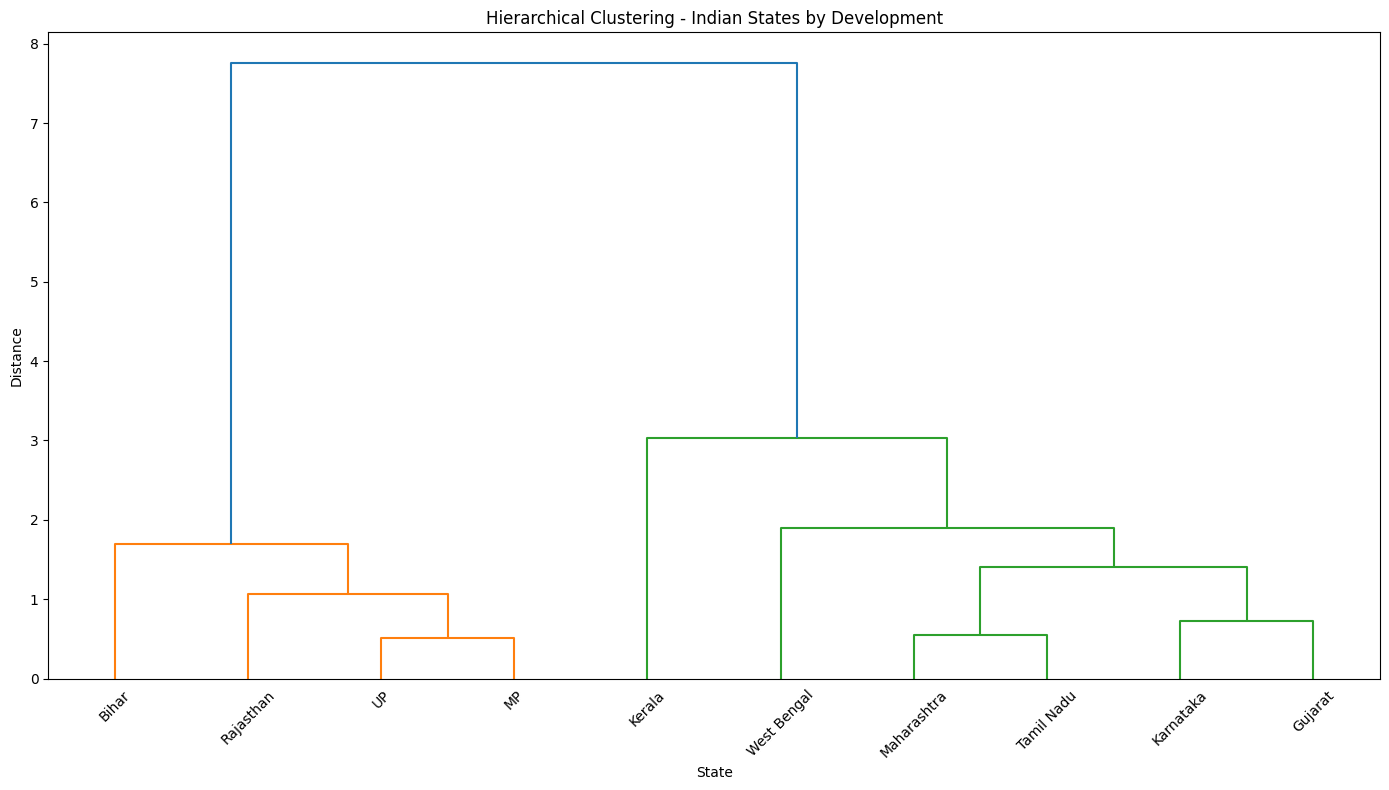

In [3]:
# === CREATE DENDROGRAM ===
plt.figure(figsize=(14, 8))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, labels=df['state'].values, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering - Indian States by Development')
plt.xlabel('State')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('states_dendrogram.png', dpi=150)
plt.show()

In [4]:
# === FIND OPTIMAL CLUSTERS ===
print(f"\n=== EVALUATION FOR DIFFERENT CLUSTER COUNTS ===")
for n_clusters in range(2, 6):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    print(f"Clusters={n_clusters}: Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")


=== EVALUATION FOR DIFFERENT CLUSTER COUNTS ===
Clusters=2: Silhouette=0.5998, Davies-Bouldin=0.4721
Clusters=3: Silhouette=0.4962, Davies-Bouldin=0.4063
Clusters=4: Silhouette=0.3741, Davies-Bouldin=0.3545
Clusters=5: Silhouette=0.2833, Davies-Bouldin=0.3464


In [5]:
# === FINAL CLUSTERING WITH 3 CLUSTERS ===
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['development_tier'] = model.fit_predict(X_scaled)

In [6]:
# Evaluation
print(f"\n=== FINAL MODEL EVALUATION ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['development_tier']):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df['development_tier']):.4f}")

# Analyze clusters
print(f"\n=== STATE DEVELOPMENT TIERS ===")
tier_names = {0: 'Developed', 1: 'Developing', 2: 'Underdeveloped'}
for tier in sorted(df['development_tier'].unique()):
    states = df[df['development_tier'] == tier]['state'].tolist()
    avg_lit = df[df['development_tier'] == tier]['literacy_rate'].mean()
    avg_income = df[df['development_tier'] == tier]['per_capita_income_k'].mean()
    print(f"\nTier {tier}: {tier_names.get(tier, 'Unknown')}")
    print(f"  States: {', '.join(states)}")
    print(f"  Avg Literacy: {avg_lit:.1f}%")
    print(f"  Avg Per Capita Income: ₹{avg_income:.0f}K")


=== FINAL MODEL EVALUATION ===
Silhouette Score: 0.4962
Davies-Bouldin Index: 0.4063

=== STATE DEVELOPMENT TIERS ===

Tier 0: Developed
  States: Maharashtra, Karnataka, Tamil Nadu, Gujarat, West Bengal
  Avg Literacy: 78.4%
  Avg Per Capita Income: ₹162K

Tier 1: Developing
  States: UP, Bihar, MP, Rajasthan
  Avg Literacy: 66.5%
  Avg Per Capita Income: ₹69K

Tier 2: Underdeveloped
  States: Kerala
  Avg Literacy: 94.0%
  Avg Per Capita Income: ₹180K



=== Indian States Development Data ===
         state  literacy_rate  per_capita_income_k  life_expectancy  \
0  Maharashtra             82                  190               72   
1           UP             68                   65               64   
2       Kerala             94                  180               75   
3        Bihar             62                   40               62   
4    Karnataka             75                  170               70   
5   Tamil Nadu             80                  165               72   
6           MP             70                   75               65   
7      Gujarat             78                  185               71   
8    Rajasthan             66                   95               67   
9  West Bengal             77                  100               70   

   infant_mortality  
0                19  
1                43  
2                10  
3                38  
4                24  
5                17  
6                47  
7 

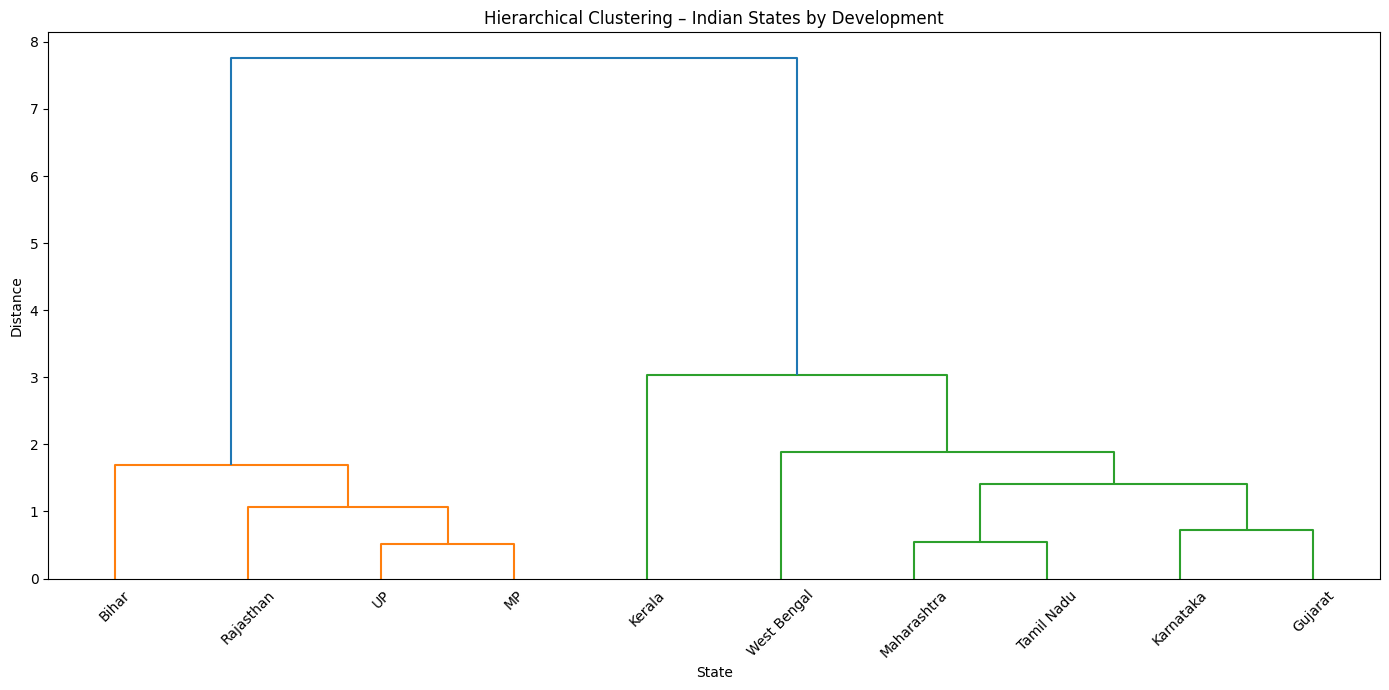


=== EVALUATION FOR DIFFERENT CLUSTER COUNTS ===
Clusters=2: Silhouette=0.5998, Davies-Bouldin=0.4721
Clusters=3: Silhouette=0.4962, Davies-Bouldin=0.4063
Clusters=4: Silhouette=0.3741, Davies-Bouldin=0.3545
Clusters=5: Silhouette=0.2833, Davies-Bouldin=0.3464

=== FINAL MODEL EVALUATION ===
Silhouette Score: 0.4962
Davies-Bouldin Index: 0.4063

=== STATE DEVELOPMENT GROUPS (DATA-DRIVEN) ===
         literacy_rate  per_capita_income_k  life_expectancy  infant_mortality
cluster                                                                       
0                 78.4                162.0             71.0              23.0
1                 66.5                 68.8             64.5              42.2
2                 94.0                180.0             75.0              10.0

Industrial / High Development
States: Maharashtra, Karnataka, Tamil Nadu, Gujarat, West Bengal

Low Development
States: UP, Bihar, MP, Rajasthan

High Human Development (Outlier)
States: Kerala


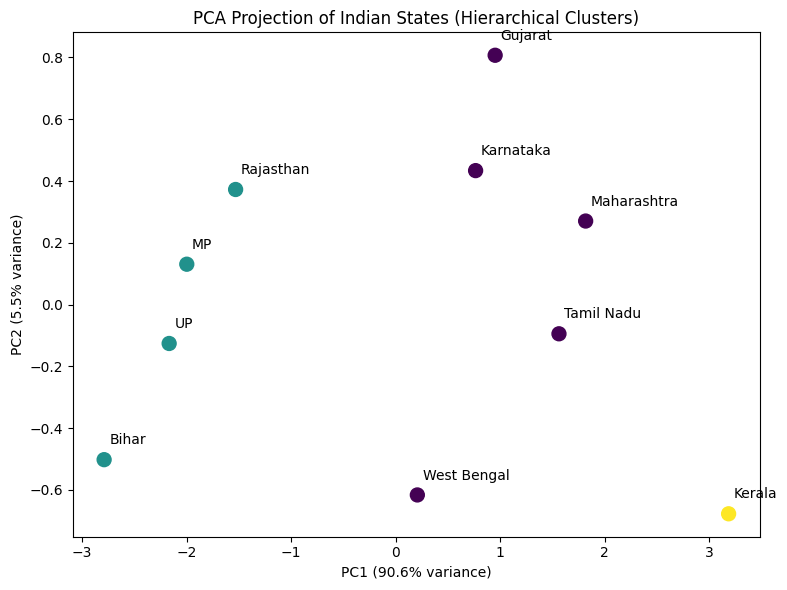

In [7]:
# ============================================================
# HIERARCHICAL CLUSTERING - COMPLETE WITH EVALUATION (CORRECT)
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CREATE DATA
# ------------------------------------------------------------
state_data = {
    'state': ['Maharashtra', 'UP', 'Kerala', 'Bihar', 'Karnataka',
              'Tamil Nadu', 'MP', 'Gujarat', 'Rajasthan', 'West Bengal'],
    'literacy_rate': [82, 68, 94, 62, 75, 80, 70, 78, 66, 77],
    'per_capita_income_k': [190, 65, 180, 40, 170, 165, 75, 185, 95, 100],
    'life_expectancy': [72, 64, 75, 62, 70, 72, 65, 71, 67, 70],
    'infant_mortality': [19, 43, 10, 38, 24, 17, 47, 30, 41, 25]
}

df = pd.DataFrame(state_data)
print("\n=== Indian States Development Data ===")
print(df)

# ------------------------------------------------------------
# 2. FEATURE PREPARATION
# ------------------------------------------------------------
features = ['literacy_rate', 'per_capita_income_k',
            'life_expectancy', 'infant_mortality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# ------------------------------------------------------------
# 3. DENDROGRAM (STRUCTURE DISCOVERY)
# ------------------------------------------------------------
plt.figure(figsize=(14, 7))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(
    linkage_matrix,
    labels=df['state'].values,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering – Indian States by Development')
plt.xlabel('State')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. CLUSTER EVALUATION
# ------------------------------------------------------------
print("\n=== EVALUATION FOR DIFFERENT CLUSTER COUNTS ===")
for k in range(2, 6):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    print(
        f"Clusters={k}: "
        f"Silhouette={silhouette_score(X_scaled, labels):.4f}, "
        f"Davies-Bouldin={davies_bouldin_score(X_scaled, labels):.4f}"
    )

# ------------------------------------------------------------
# 5. FINAL MODEL (k = 3 – BEST BALANCE)
# ------------------------------------------------------------
final_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster'] = final_model.fit_predict(X_scaled)

print("\n=== FINAL MODEL EVALUATION ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['cluster']):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df['cluster']):.4f}")

# ------------------------------------------------------------
# 6. DATA-DRIVEN CLUSTER INTERPRETATION (CORRECT)
# ------------------------------------------------------------
print("\n=== STATE DEVELOPMENT GROUPS (DATA-DRIVEN) ===")

cluster_summary = (
    df.groupby('cluster')[features]
    .mean()
    .round(1)
)

print(cluster_summary)

# Assign meaningful labels AFTER inspection
cluster_labels = {
    0: "Industrial / High Development",
    1: "Low Development",
    2: "High Human Development (Outlier)"
}

df['development_category'] = df['cluster'].map(cluster_labels)

for c in sorted(df['cluster'].unique()):
    states = df[df['cluster'] == c]['state'].tolist()
    print(f"\n{cluster_labels[c]}")
    print(f"States: {', '.join(states)}")

# ------------------------------------------------------------
# 7. OPTIONAL: PCA FOR BETTER VISUALIZATION
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], s=100)

for i, state in enumerate(df['state']):
    plt.annotate(state, (X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05))

plt.title('PCA Projection of Indian States (Hierarchical Clusters)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()
